In [40]:
import h5py

file_path = r"Dataset/archive/GOLD_XYZ_OSC.0001_1024.hdf5"

with h5py.File(file_path, "r") as f:
    print("Keys:")
    for key in f.keys():
        print(key)

Keys:
X
Y
Z


In [41]:
with h5py.File(file_path, "r") as f:
    for key in f.keys():
        print(key, f[key].shape)

X (2555904, 1024, 2)
Y (2555904, 24)
Z (2555904, 1)


In [42]:
import h5py
import numpy as np



with h5py.File(file_path, "r") as f:
    X = f["X"]
    Y = f["Y"]
    Z = f["Z"]

    print("X shape:", X.shape)
    print("Y shape:", Y.shape)
    print("Z shape:", Z.shape)

    print("\nFirst Y:")
    print(Y[0])

    print("\nFirst Z:")
    print(Z[0])

    print("\nX[0] shape:")
    print(X[0].shape)

    print("\nFirst 5 IQ samples:")
    print(X[0][:120])

X shape: (2555904, 1024, 2)
Y shape: (2555904, 24)
Z shape: (2555904, 1)

First Y:
[1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]

First Z:
[-20]

X[0] shape:
(1024, 2)

First 5 IQ samples:
[[ 4.20273952e-02  2.34763235e-01]
 [-2.72882611e-01  4.05134916e-01]
 [-2.67072618e-01  2.27498889e-01]
 [-3.14850867e-01 -1.76458597e-01]
 [ 9.63341236e-01 -1.02571023e+00]
 [ 1.87244624e-01  6.44536376e-01]
 [ 2.60705411e-01 -4.00602192e-01]
 [-1.38889417e-01  3.37220818e-01]
 [ 3.51226389e-01 -3.00818056e-01]
 [ 6.83884501e-01 -1.90601695e+00]
 [ 1.19307786e-01  7.23491237e-02]
 [-1.77766070e-01 -3.49935830e-01]
 [ 4.21254300e-02 -2.73146898e-01]
 [ 1.16819859e+00  1.35799253e+00]
 [ 1.13426137e+00  4.34401125e-01]
 [ 3.39727253e-02 -9.00930226e-01]
 [ 1.82389474e+00 -1.91117674e-01]
 [ 1.11155123e-01  3.19545120e-01]
 [ 8.38508904e-01  3.62890035e-01]
 [ 1.07418180e+00  3.98637831e-01]
 [ 3.25316995e-01 -5.00284135e-01]
 [-7.12064922e-01 -2.04506859e-01]
 [-5.76841295e-01  1.49948746e-01]
 [

In [43]:
f= h5py.File(file_path , "r")

In [44]:
X

<Closed HDF5 dataset>

In [45]:
import h5py

f = h5py.File("Dataset/archive/GOLD_XYZ_OSC.0001_1024.hdf5", "r")
x = f["X"]
print(x[0].shape)

(1024, 2)


In [46]:
y= f["Y"]
z=f["Z"]
labels = np.argmax(y , axis = 1)

In [47]:
print("Class IDs:", np.unique(labels))

Class IDs: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23]


In [48]:
import json
with open(r"Dataset/archive/classes-fixed.json" , "r") as f:
    classes = json.load(f)
print(classes)

['OOK', '4ASK', '8ASK', 'BPSK', 'QPSK', '8PSK', '16PSK', '32PSK', '16APSK', '32APSK', '64APSK', '128APSK', '16QAM', '32QAM', '64QAM', '128QAM', '256QAM', 'AM-SSB-WC', 'AM-SSB-SC', 'AM-DSB-WC', 'AM-DSB-SC', 'FM', 'GMSK', 'OQPSK']


In [49]:
sample = x[319488]
sample.shape

(1024, 2)

In [50]:
sample[:10]

array([[-0.50679684,  0.4923161 ],
       [-0.7730785 ,  0.88742954],
       [ 1.0520872 ,  0.29016516],
       [ 1.0212482 , -0.17397913],
       [ 1.1298447 , -0.23737437],
       [ 1.6448045 , -0.36923006],
       [ 0.93749446,  1.4951981 ],
       [-0.13867494,  0.4566157 ],
       [-0.15407032,  0.10436989],
       [ 0.48751155,  1.4139289 ]], dtype=float32)

In [51]:
label = np.argmax(y[319488])
snr = z[319488][0]

In [52]:
print("Class ID:", label)
print("Modulation:", classes[label])
print("SNR:", snr, "dB")

Class ID: 3
Modulation: BPSK
SNR: -20 dB


In [53]:
for i in [0, 4096, 8192, 106496, 106498]:
    print(i, np.argmax(y[i]), z[i][0])

0 0 -20
4096 0 -18
8192 0 -16
106496 1 -20
106498 1 -20


Text(0, 0.5, 'Amplitude')

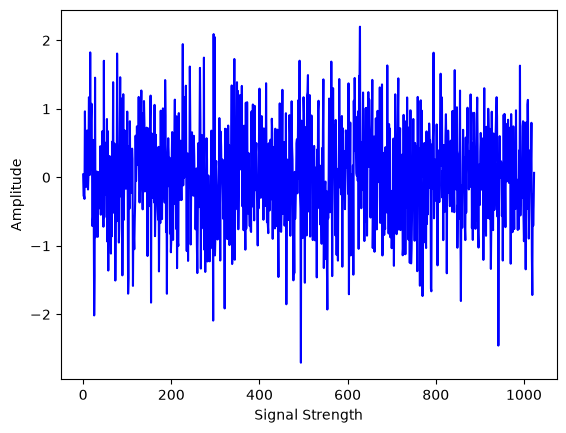

In [65]:
# Now I will plot te see how the signal works
import matplotlib.pyplot as plt
first = x[0]

plt.plot(first[: , 0] , color = "blue" )
plt.xlabel("Signal Strength")
plt.ylabel("Amplitude")

Text(0, 0.5, 'Amplitude')

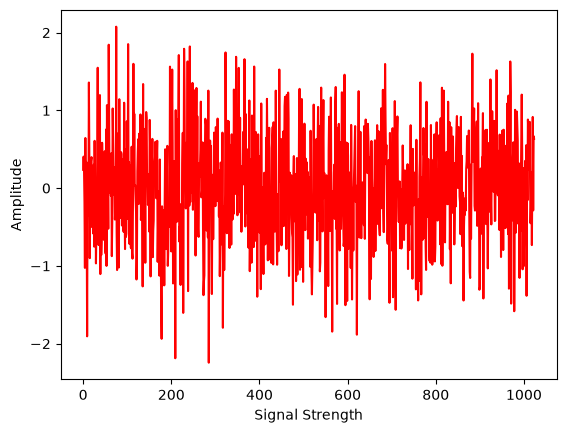

In [66]:
plt.plot( first[: ,1] , color = "red" )
plt.xlabel("Signal Strength")
plt.ylabel("Amplitude")

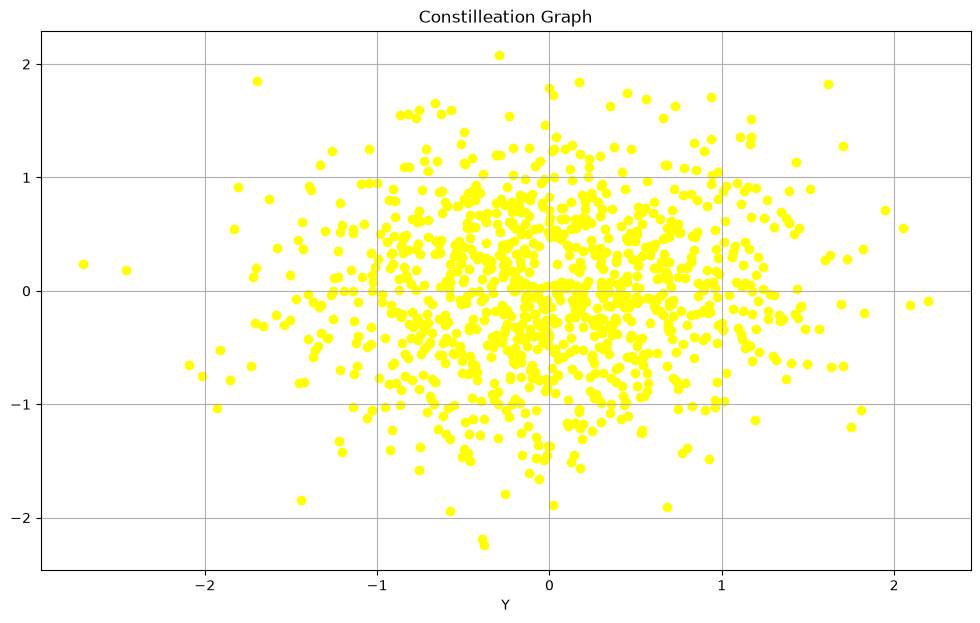

In [70]:
plt.figure(figsize=(12,7))
plt.scatter(first[: , 0] , first[: ,1] , color = "yellow" )

plt.xlabel("X")
plt.xlabel("Y")
plt.title("Constilleation Graph")

plt.grid()


In [57]:
for i in [0,100,189000,10000,969999]:
    label = np.argmax(y[i])
    snr = z[i][0]
    print(f"{i}-->{classes[label]} --> {snr}"
        
    )
    


0-->OOK --> -20
100-->OOK --> -20
189000-->4ASK --> 20
10000-->OOK --> -16
969999-->32APSK --> -16


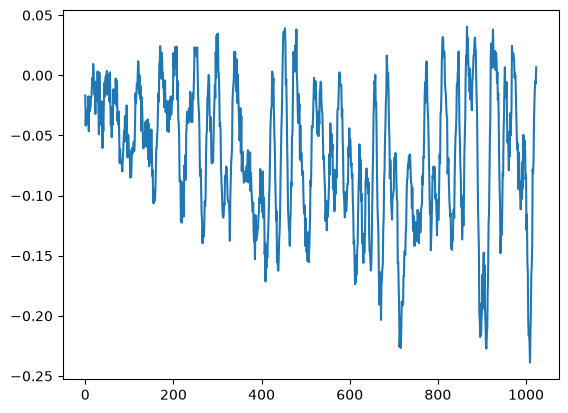

In [58]:
g = 189000
s1 = x[g]
i = s1[: , 0]
q=s1[: ,1]
plt.plot(i)

In [59]:
print(np.unique(z))

[-20 -18 -16 -14 -12 -10  -8  -6  -4  -2   0   2   4   6   8  10  12  14
  16  18  20  22  24  26  28  30]


In [60]:
for i in np.unique(z[:,0]):
    count = np.sum(z[:, 0] == i)
    print(f"{i} --> {count}")

-20 --> 98304
-18 --> 98304
-16 --> 98304
-14 --> 98304
-12 --> 98304
-10 --> 98304
-8 --> 98304
-6 --> 98304
-4 --> 98304
-2 --> 98304
0 --> 98304
2 --> 98304
4 --> 98304
6 --> 98304
8 --> 98304
10 --> 98304
12 --> 98304
14 --> 98304
16 --> 98304
18 --> 98304
20 --> 98304
22 --> 98304
24 --> 98304
26 --> 98304
28 --> 98304
30 --> 98304


In [61]:
for g in np.unique(labels):
    count = np.sum(labels == g)
    print(f"{classes[g]}--> {count}")

OOK--> 106496
4ASK--> 106496
8ASK--> 106496
BPSK--> 106496
QPSK--> 106496
8PSK--> 106496
16PSK--> 106496
32PSK--> 106496
16APSK--> 106496
32APSK--> 106496
64APSK--> 106496
128APSK--> 106496
16QAM--> 106496
32QAM--> 106496
64QAM--> 106496
128QAM--> 106496
256QAM--> 106496
AM-SSB-WC--> 106496
AM-SSB-SC--> 106496
AM-DSB-WC--> 106496
AM-DSB-SC--> 106496
FM--> 106496
GMSK--> 106496
OQPSK--> 106496


In [62]:
for i in range (0,500000 , 50000):
    label = np.argmax(y[i])
    print(label)

0
0
0
1
1
2
2
3
3
4


In [63]:
no=1096
label = np.argmax(y[no])
label
classes[label]

'OOK'

In [99]:
x[0]


array([[ 0.0420274 ,  0.23476323],
       [-0.2728826 ,  0.40513492],
       [-0.26707262,  0.22749889],
       ...,
       [-0.7055947 , -0.28693035],
       [-0.41157472,  0.66826206],
       [ 0.06487698,  0.6358149 ]], shape=(1024, 2), dtype=float32)

In [100]:
for i in range (0 , 100):
    for j in [0]:
        val = x[0][i][j]
        val1 = x[0][i][j+1]
        d = (val)**2 + (val)**2
        print(np.sqrt(d))
        
        

0.05943571
0.3859143
0.3776977
0.44526637
1.3623703
0.2648039
0.3686931
0.1964193
0.49670914
0.96715873
0.1687267
0.2513992
0.059574354
1.6520823
1.6040878
0.04804469
2.5793767
0.15719709
1.1858306
1.5191225
0.4600677
1.0070119
0.81577677
0.77156436
0.7150778
2.8514025
2.0310934
2.0572903
1.2367038
0.5590294
0.28267258
0.11899959
0.13456924
1.2297359
0.11079021
0.12262378
0.03480202
0.6383308
0.40940446
0.6425057
0.772211
0.020265548
0.2813293
0.2084861
0.9574126
0.31036985
1.0199449
2.4065344
0.8274865
0.06459589
0.030100146
0.71447784
0.3642017
0.3082762
1.2040268
1.328984
0.9536538
1.9247203
0.242059
0.75298667
0.4395975
0.20485796
0.8158514
1.5747147
0.3388151
1.2180427
0.7372664
0.3026245
1.9643414
0.35425064
0.7335391
0.69804406
0.0001913834
2.1310523
0.9066715
0.40986744
0.9062957
2.5556962
0.75518095
0.21314935
0.60826325
1.3463455
1.0311958
0.8055839
2.0663264
0.39280742
0.95077735
0.29445612
1.628492
2.0242887
0.09346916
1.7165192
0.8807573
0.11622352
0.96999675
0.08409884
0.

In [103]:
no_of_samples = 106496
samples_per_snr = 4096
sample_take = 100
X_list = []
Y_list = []
Z_list = []
for class_id in range (24):
    class_start = no_of_samples * class_id
    for snr_id in range (26):
        start = class_start + snr_id*samples_per_snr
        end = start + sample_take
        X_list.append(x[start:end])
        Y_list.append(y[start:end])
        Z_list.append(z[start:end])
X_subset = np.concatenate(X_list , axis=0)
Y_subset = np.concatenate(Y_list , axis=0)
Z_subset = np.concatenate(Z_list , axis=0)
        
        
    

In [104]:
print("X_subset:", X_subset.shape)
print("Y_subset:", Y_subset.shape)
print("Z_subset:", Z_subset.shape)

X_subset: (62400, 1024, 2)
Y_subset: (62400, 24)
Z_subset: (62400, 1)


In [105]:
Y_subset

array([[1, 0, 0, ..., 0, 0, 0],
       [1, 0, 0, ..., 0, 0, 0],
       [1, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 1],
       [0, 0, 0, ..., 0, 0, 1],
       [0, 0, 0, ..., 0, 0, 1]], shape=(62400, 24))

In [108]:
label1 = np.argmax(Y_subset , axis=1)


In [115]:
#  Amplitude for the extracted data 
I = X_subset[: , : ,0]
Q = X_subset[: , : ,1]
amplitude = np.sqrt(I**2+Q**2)
amplitude.shape

(62400, 1024)

In [116]:
amplitude

array([[0.23849545, 0.48846617, 0.35083264, ..., 0.76170397, 0.78483623,
        0.6391163 ],
       [1.2800881 , 0.56176436, 0.9292343 , ..., 1.3727944 , 0.8803472 ,
        1.095594  ],
       [0.28784263, 0.9363751 , 0.7517672 , ..., 0.75989723, 0.36345   ,
        0.5922116 ],
       ...,
       [1.4377888 , 1.2551689 , 1.0266075 , ..., 1.0809884 , 0.93070626,
        0.71296805],
       [0.37008023, 0.27605864, 0.29826707, ..., 1.0140576 , 1.0280325 ,
        1.0428339 ],
       [0.5902222 , 0.8003705 , 0.93313843, ..., 1.1640813 , 1.1522086 ,
        1.1453786 ]], shape=(62400, 1024), dtype=float32)

In [120]:
amp_mean = amplitude.mean(axis=1)
amp_std = amplitude.std(axis=1)
amp_max = amplitude.max(axis=1)
